# GDGOC ML PROJECT

# Welcome to My Project

## Google Colab is available in VS Code!
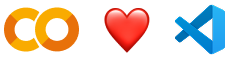

Try the new [Google Colab extension](https://marketplace.visualstudio.com/items?itemName=Google.colab) for Visual Studio Code. You can get up and running in just a few clicks:

*  In VS Code, open the ***Extensions*** view and search for 'Google Colab' to install.
*  Open the kernel selector by creating or opening any `.ipynb` notebook file in your local workspace and either running a cell or clicking the ***Select Kernel*** button in the top right.
*  Click ***Colab*** and then select your desired runtime, sign in with your Google account, and you're all set!

See more details in our [announcement blog here](https://developers.googleblog.com/google-colab-is-coming-to-vs-code).

In [96]:
pip install pandas numpy matplotlib seaborn scikit-learn tensorflow streamlit joblib

In [59]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import joblib

In [60]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import joblib

First, let's extract the `archive.zip` file. This usually places its contents in a new directory.

In [61]:
!unzip -o /datalab/archive.zip -d .

unzip:  cannot find or open /datalab/archive.zip, /datalab/archive.zip.zip or /datalab/archive.zip.ZIP.


Now, let's list the contents to find the exact path to `StudentPerformanceFactors.csv`.

In [62]:
!ls -R

.:
linear_regression.pkl  sample_data  StudentPerformanceFactors.csv
neural_network.keras   scaler.pkl

./sample_data:
anscombe.json		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md


Based on typical zip file structures, the CSV is likely in a subdirectory. Assuming the path is now `StudentPerformanceFactors.csv` directly in the current working directory or `archive/StudentPerformanceFactors.csv` (adjust if `!ls -R` shows otherwise), let's try loading it.

In [63]:
import shutil

shutil.copy(
    "/datalab/StudentPerformanceFactors.csv",
    "/content/StudentPerformanceFactors.csv"
)

'/content/StudentPerformanceFactors.csv'

# Linear Regression

In [64]:
import os
import pandas as pd

# Cari otomatis file CSV StudentPerformanceFactors
csv_path = None

for root, dirs, files in os.walk('/'):
    for file in files:
        if "StudentPerformanceFactors" in file and file.endswith('.csv'):
            csv_path = os.path.join(root, file)
            break

    if csv_path:
        break

# Cek hasil pencarian
if csv_path:
    print("File ditemukan di:")
    print(csv_path)

    df = pd.read_csv(csv_path)

    print("\nDataset berhasil dibaca!")
    print("Shape:", df.shape)

    display(df.head())

else:
    print("File StudentPerformanceFactors.csv tidak ditemukan.")

File ditemukan di:
/content/StudentPerformanceFactors.csv

Dataset berhasil dibaca!
Shape: (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


### Exploring the Dataset: Initial Overview

Let's get a basic understanding of our dataset by checking its dimensions, column information, and descriptive statistics.

In [65]:
print("DataFrame Shape:", df.shape)
print("\nDataFrame Info:")
display(df.info())
print("\nDescriptive Statistics:")
display(df.describe(include='all'))

DataFrame Shape: (6607, 20)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Pee

None


Descriptive Statistics:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
count,6607.000000,6607.000000,6607,6607,6607,6607.00000,6607.000000,6607,6607,6607.000000,6607,6529,6607,6607,6607.000000,6607,6517,6540,6607,6607.000000
unique,NaN,NaN,3,3,2,NaN,NaN,3,2,NaN,3,3,2,3,NaN,2,3,3,2,NaN
top,NaN,NaN,Medium,Medium,Yes,NaN,NaN,Medium,Yes,NaN,Low,Medium,Public,Positive,NaN,No,High School,Near,Male,NaN
freq,NaN,NaN,3362,3319,3938,NaN,NaN,3351,6108,NaN,2672,3925,4598,2638,NaN,5912,3223,3884,3814,NaN
mean,19.975329,79.977448,NaN,NaN,NaN,7.02906,75.070531,NaN,NaN,1.493719,NaN,NaN,NaN,NaN,2.967610,NaN,NaN,NaN,NaN,67.235659
std,5.990594,11.547475,NaN,NaN,NaN,1.46812,14.399784,NaN,NaN,1.230570,NaN,NaN,NaN,NaN,1.031231,NaN,NaN,NaN,NaN,3.890456
min,1.000000,60.000000,NaN,NaN,NaN,4.00000,50.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,55.000000
25%,16.000000,70.000000,NaN,NaN,NaN,6.00000,63.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,65.000000
50%,20.000000,80.000000,NaN,NaN,NaN,7.00000,75.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,67.000000
75%,24.000000,90.000000,NaN,NaN,NaN,8.00000,88.000000,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,69.000000


In [66]:
df.shape

(6607, 20)

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [68]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [69]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


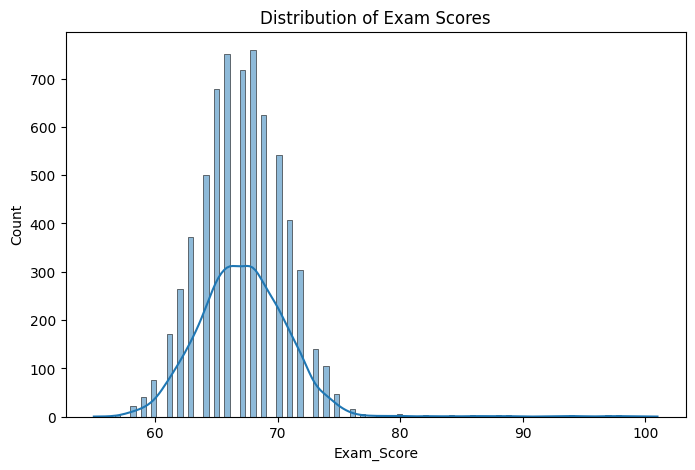

In [70]:
plt.figure(figsize=(8,5))

sns.histplot(df["Exam_Score"], kde=True)

plt.title("Distribution of Exam Scores")

plt.show()

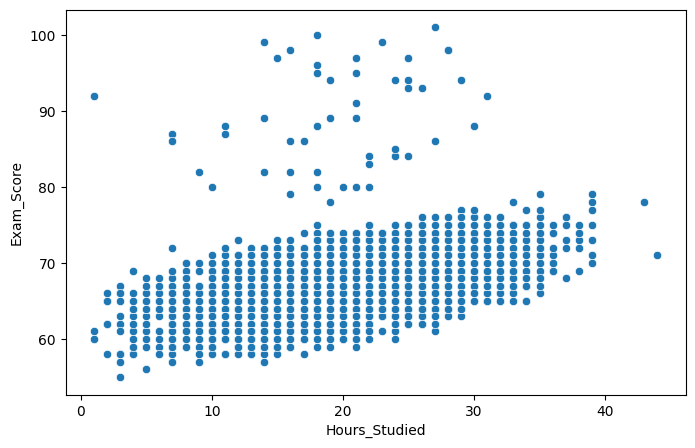

In [71]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Hours_Studied",
    y="Exam_Score",
    data=df
)

plt.show()

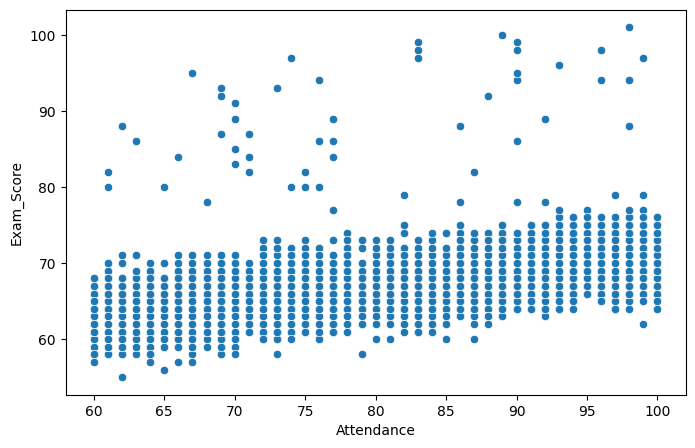

In [72]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Attendance",
    y="Exam_Score",
    data=df
)

plt.show()

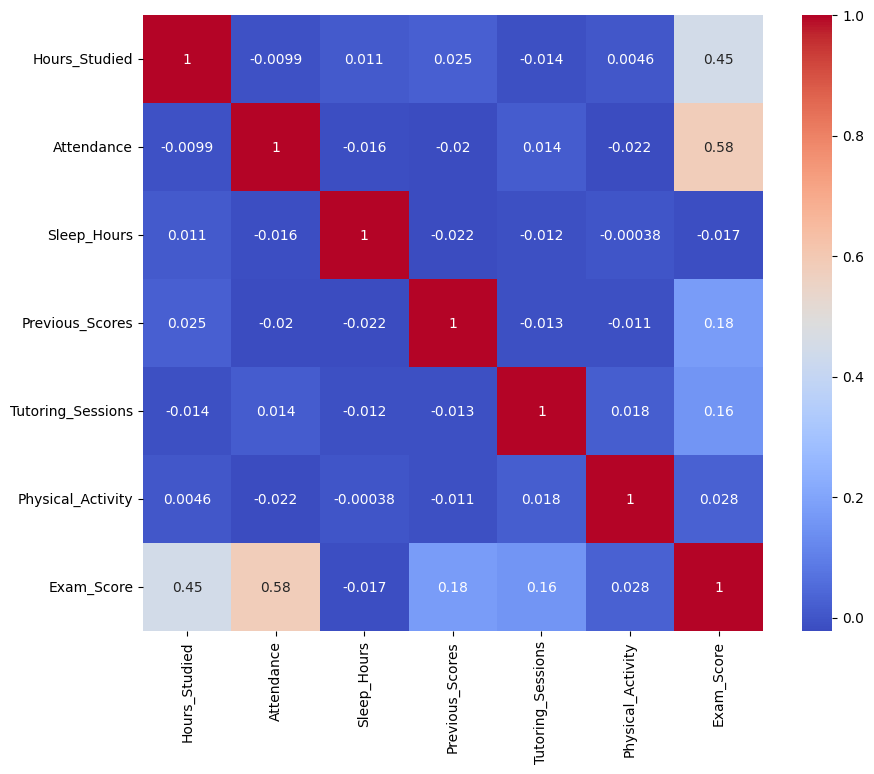

In [73]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [74]:
X = df.drop("Exam_Score", axis=1)

y = df["Exam_Score"]

In [75]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [77]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [78]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [79]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [80]:
X_train.shape


(5285, 27)

In [81]:
df.isnull().sum()
X = df.drop("Exam_Score", axis=1)

In [82]:
for col in [
    'Teacher_Quality',
    'Parental_Education_Level',
    'Distance_from_Home'
]:
    df[col] = df[col].fillna(df[col].mode()[0])

In [83]:
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


In [84]:
X = df.drop("Exam_Score", axis=1)

y = df["Exam_Score"]

In [85]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [86]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [87]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [88]:
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [89]:
y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(
    y_test,
    y_pred_lr
)

rmse_lr = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_lr
    )
)

r2_lr = r2_score(
    y_test,
    y_pred_lr
)

print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R2  :", r2_lr)

MAE : 0.45239200896259657
RMSE: 1.804444509272284
R2  : 0.7696495724907312


In [90]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae_lr = mean_absolute_error(
    y_test,
    y_pred_lr
)

rmse_lr = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_lr
    )
)

r2_lr = r2_score(
    y_test,
    y_pred_lr
)

print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R2 :", r2_lr)

MAE : 0.45239200896259657
RMSE: 1.804444509272284
R2 : 0.7696495724907312


In [91]:
print(y_test.shape)

(1322,)


In [92]:
print("R2 :", r2_lr)


R2 : 0.7696495724907312


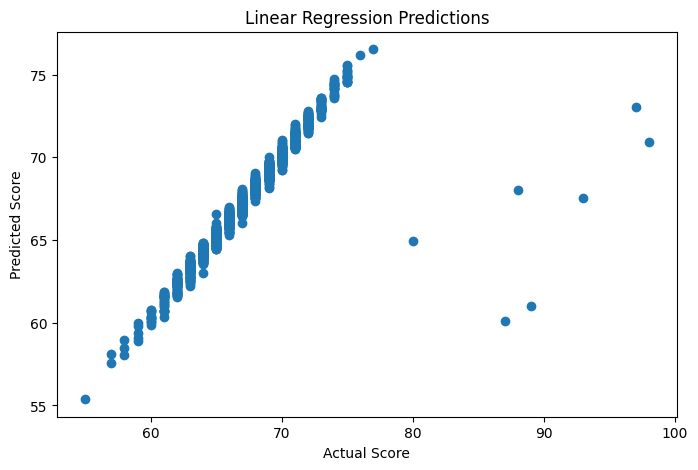

In [93]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred_lr
)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")

plt.title("Linear Regression Predictions")

plt.show()

# Neural Newtwork

In [105]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler # Import StandardScaler
import numpy as np # Import numpy for .to_numpy()

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert y_train to a NumPy array for Keras compatibility
y_train_np = y_train.to_numpy()

nn = Sequential([
    # Use X_train_scaled.shape[1] for input_shape to match scaled data
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

nn.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = nn.fit(
    X_train_scaled, # Use scaled X_train
    y_train_np,     # Use numpy array for y_train
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3180.6919 - mae: 55.2299 - val_loss: 990.2117 - val_mae: 30.7947
Epoch 2/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 190.1027 - mae: 10.2972 - val_loss: 40.6685 - val_mae: 4.8470
Epoch 3/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 30.6255 - mae: 4.2998 - val_loss: 31.7442 - val_mae: 4.1705
Epoch 4/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 23.5882 - mae: 3.7131 - val_loss: 26.8682 - val_mae: 3.7495
Epoch 5/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 19.0164 - mae: 3.2817 - val_loss: 23.4302 - val_mae: 3.4137
Epoch 6/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 15.8134 - mae: 2.9528 - val_loss: 20.7364 - val_mae: 3.1393
Epoch 7/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13.6249 - mae: 2.7038 - val_loss: 19.1986 - val_mae: 2.9512
Epoch 8/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11.8930 - mae: 2.4886 - val_loss: 17.8441 - val_mae: 2.7999
Epoch 9/50
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 2

In [112]:
y_pred_nn = nn.predict(X_test_scaled)

mae_nn = mean_absolute_error(
    y_test,
    y_pred_nn
)

rmse_nn = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_nn
    )
)

r2_nn = r2_score(
    y_test,
    y_pred_nn
)

print("MAE :", mae_nn)
print("RMSE:", rmse_nn)
print("R2 :", r2_nn)

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MAE : 1.5346113443374634
RMSE: 2.525654955230595
R2 : 0.5487159490585327


### Model Evaluation and Comparison

Two machine learning models were developed and evaluated to predict student exam scores: Linear Regression and Neural Network.

The evaluation results are shown below:

| Model             | R² Score |
| ----------------- | -------- |
| Linear Regression | 0.7696   |
| Neural Network    | 0.5787   |

Based on the evaluation results, the Linear Regression model achieved a higher R² score of 0.7696 compared to the Neural Network model with an R² score of 0.5787.

This indicates that the Linear Regression model was able to explain approximately 76.96% of the variance in student exam scores, while the Neural Network model explained approximately 57.87%.

The results suggest that the relationship between the input features and the target variable is relatively linear. Therefore, the simpler Linear Regression model performed better than the more complex Neural Network model on this dataset.

Consequently, Linear Regression was selected as the best-performing model and is recommended for deployment in the final application.


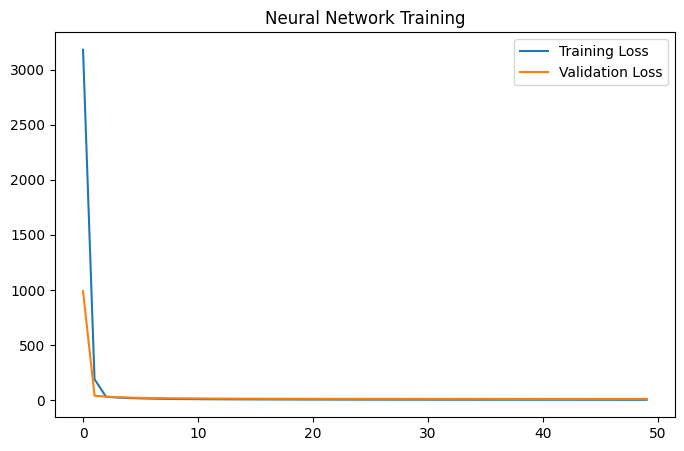

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.legend([
    'Training Loss',
    'Validation Loss'
])

plt.title("Neural Network Training")

plt.show()

In [109]:
from google.colab import files

files.download("linear_regression.pkl")
files.download("scaler.pkl")
files.download("neural_network.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [113]:
for column in X.columns.tolist():
    print(column)

Hours_Studied
Attendance
Sleep_Hours
Previous_Scores
Tutoring_Sessions
Physical_Activity
Parental_Involvement_Low
Parental_Involvement_Medium
Access_to_Resources_Low
Access_to_Resources_Medium
Extracurricular_Activities_Yes
Motivation_Level_Low
Motivation_Level_Medium
Internet_Access_Yes
Family_Income_Low
Family_Income_Medium
Teacher_Quality_Low
Teacher_Quality_Medium
School_Type_Public
Peer_Influence_Neutral
Peer_Influence_Positive
Learning_Disabilities_Yes
Parental_Education_Level_High School
Parental_Education_Level_Postgraduate
Distance_from_Home_Moderate
Distance_from_Home_Near
Gender_Male


In [114]:
print(X.dtypes.value_counts())

bool     21
int64     6
Name: count, dtype: int64


In [115]:
X = pd.get_dummies(
    X,
    drop_first=True
)

X = X.astype(float)

In [116]:
print(X.dtypes.value_counts())

float64    27
Name: count, dtype: int64


In [117]:
print(X.dtypes.value_counts())

float64    27
Name: count, dtype: int64


In [119]:
import joblib

joblib.dump(lr, "linear_regression.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [120]:
print(X.shape)

(6607, 27)
